# Author: Joffrey Ji COMP9414 26T2

# 1 Problem description

### We want to model the evolution of biomass in a bioprocess, which is periodically fed with a compound A, resulting in an increase in the mass of living matter (biomass) and a decrease - as it grows - in the existing substrate (food). A schematic of the bioprocess can be seen in Figure 1.

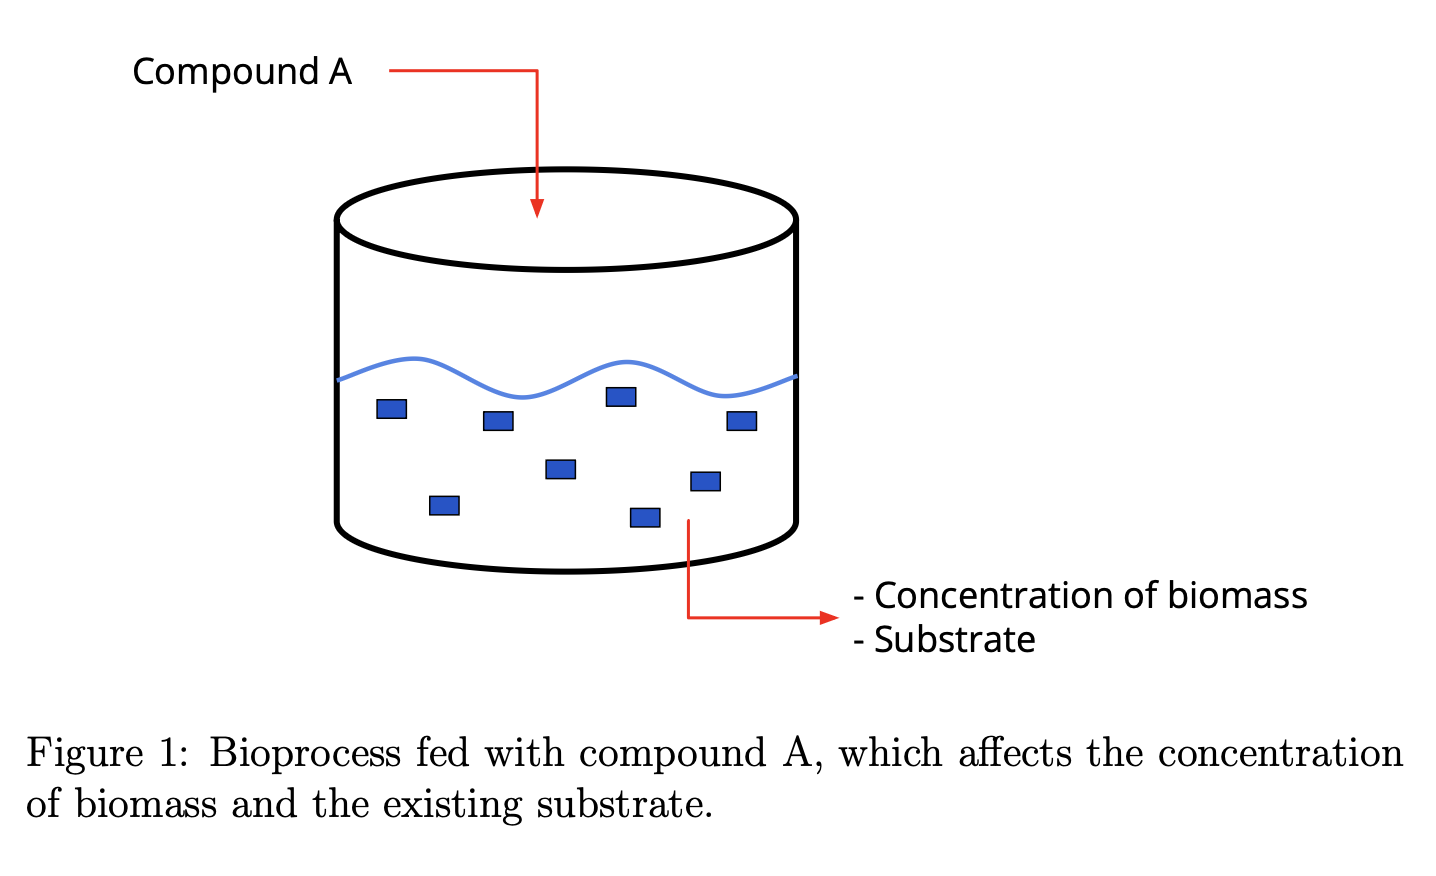

### When the bioprocess receives compound A, it increases the mass of living matter and decreases the existing substrate as it grows. The dynamics of the variables can be observed in Figure 2.

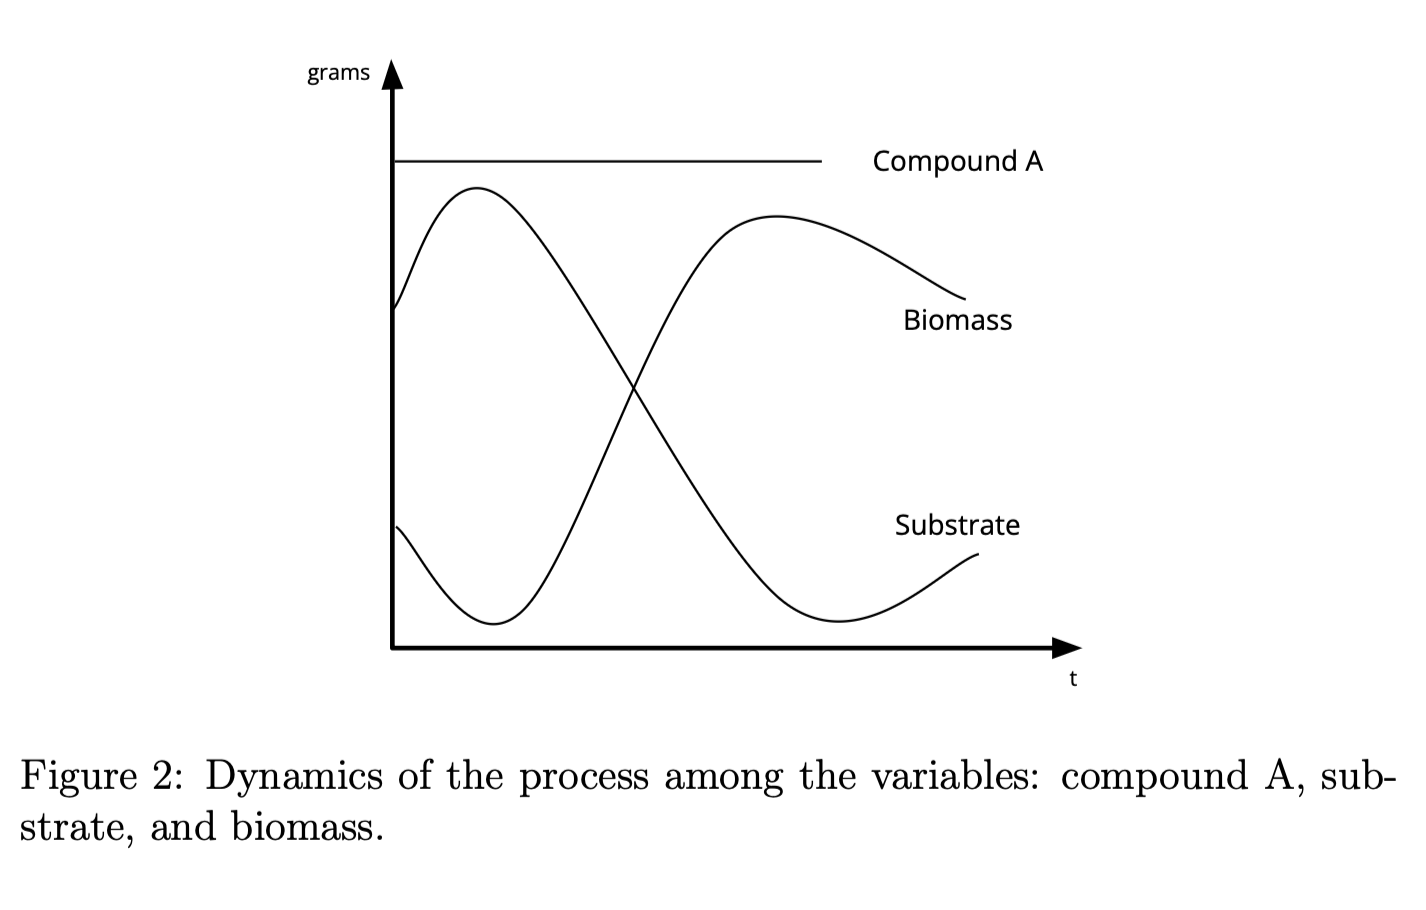

### The problem, then, consists of using a multi-layer neural network to approximate the bioprocess, where compound A and substrate are considered as inputs to the network and biomass as its output. To achieve this, the basic rules of data preprocessing, neural network design, training, and validation must be followed.

### Three data files representing the inputs and the target are available, as shown in Table 1.

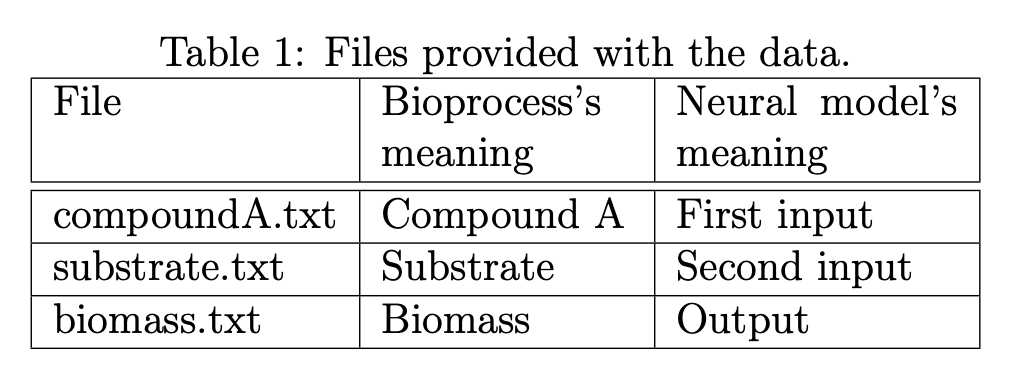



# step 1: install required libraries

In [10]:
pip install tensorflow matplotlib scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 52.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# step 2: import required libraries & setup the experiment

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler

tf.keras.utils.set_random_seed(313)  # Set global random seed for reproducible results
tf.config.experimental.enable_op_determinism()  # Ensure deterministic operations across runs

# step 3: read data and show data

2000


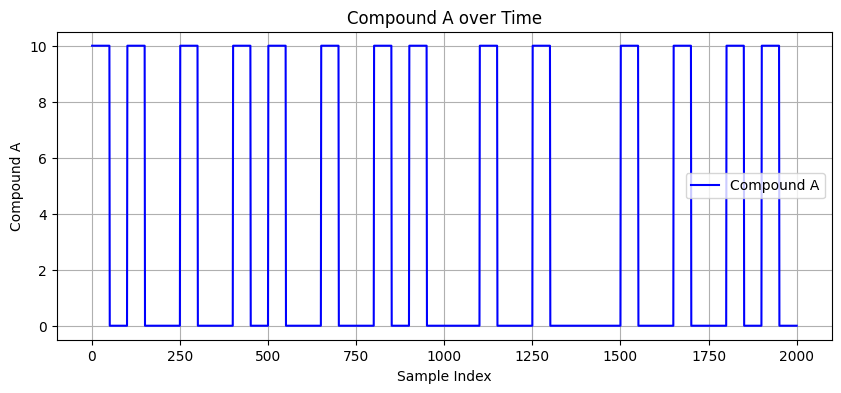

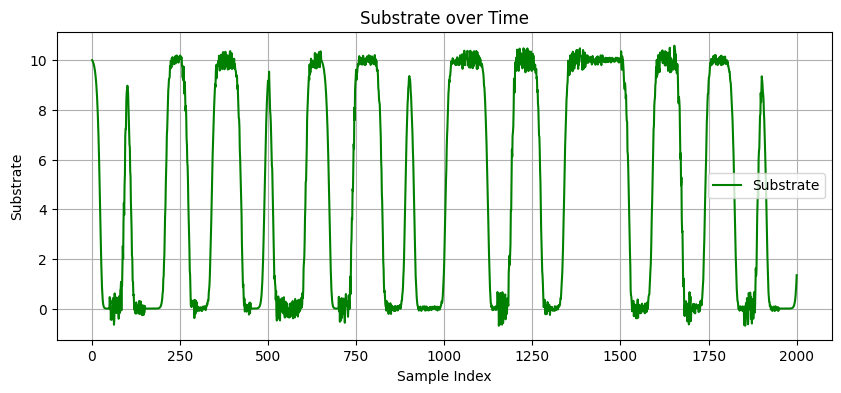

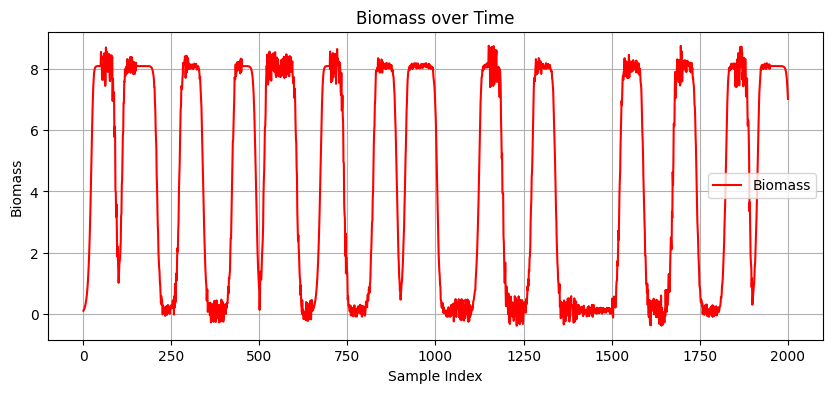

In [13]:
i1 = np.loadtxt('compoundA.txt')
i2 = np.loadtxt('substrate.txt')
t1 = np.loadtxt('biomass.txt')

# Get number of data points
maxData = np.size(t1) 
print(maxData)

x = np.arange(1, maxData + 1)

# Plot Compound A
plt.figure(figsize=(10, 4))
plt.plot(x, i1, label='Compound A', color='blue')
plt.title('Compound A over Time')
plt.xlabel('Sample Index')
plt.ylabel('Compound A')
plt.grid(True)
plt.legend()
plt.show()

# Plot Substrate
plt.figure(figsize=(10, 4))
plt.plot(x, i2, label='Substrate', color='green')
plt.title('Substrate over Time')
plt.xlabel('Sample Index')
plt.ylabel('Substrate')
plt.grid(True)
plt.legend()
plt.show()

# Plot Biomass
plt.figure(figsize=(10, 4))
plt.plot(x, t1, label='Biomass', color='red')
plt.title('Biomass over Time')
plt.xlabel('Sample Index')
plt.ylabel('Biomass')
plt.grid(True)
plt.legend()
plt.show()

# step 4:data cleaning

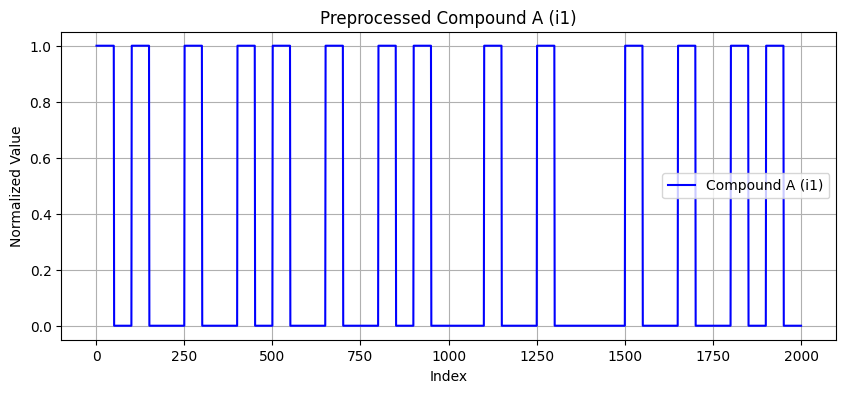

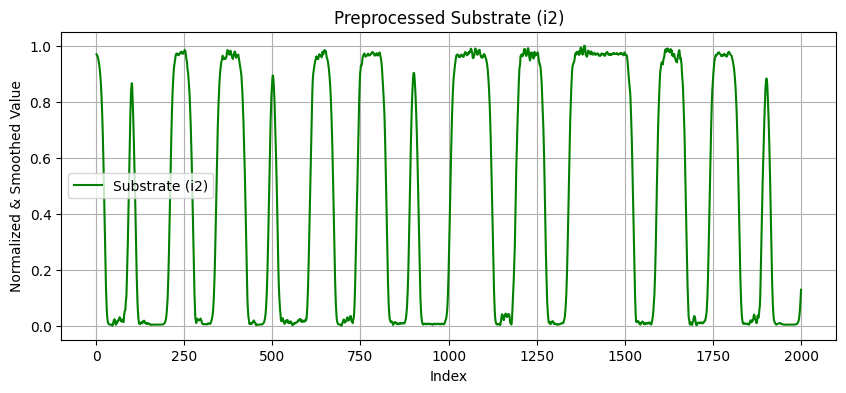

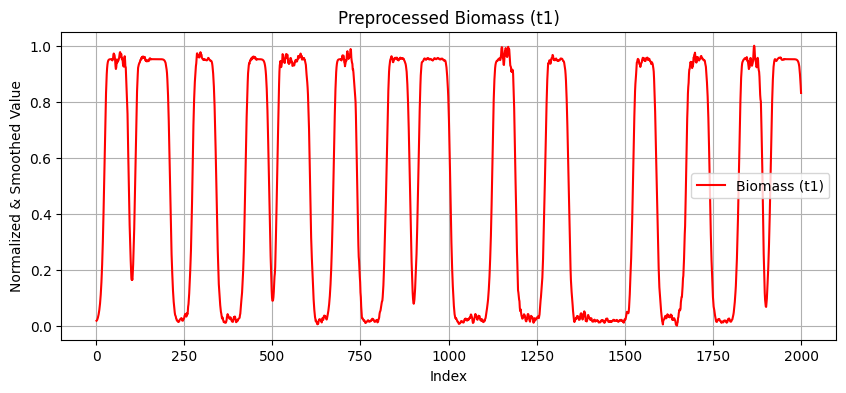

In [14]:
# === Step 1: Remove negative values ===
for i in range(0,maxData):
    if i2[i] < 0:
        i2[i] = 0
    if t1[i] < 0:
        t1[i] = 0

# === Step 2: Apply smoothing (Savitzky-Golay filter) ===
# window_length must be odd and < data length
window_length = 11 if maxData > 11 else maxData - (maxData + 1) % 2
i2 = savgol_filter(i2, window_length=window_length, polyorder=2)
t1 = savgol_filter(t1, window_length=window_length, polyorder=2)

# === Step 3: Normalize all data to [0, 1] ===
scaler = MinMaxScaler()
i1 = scaler.fit_transform(i1.reshape(-1, 1)).flatten()
i2 = scaler.fit_transform(i2.reshape(-1, 1)).flatten()
t1 = scaler.fit_transform(t1.reshape(-1, 1)).flatten()

# --- Step 4: Plot each signal in its own figure ---
x = np.arange(1, maxData + 1)

# Plot i1
plt.figure(figsize=(10, 4))
plt.plot(x, i1, label='Compound A (i1)', color='blue')
plt.title('Preprocessed Compound A (i1)')
plt.xlabel('Index')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.legend()
plt.show()

# Plot i2
plt.figure(figsize=(10, 4))
plt.plot(x, i2, label='Substrate (i2)', color='green')
plt.title('Preprocessed Substrate (i2)')
plt.xlabel('Index')
plt.ylabel('Normalized & Smoothed Value')
plt.grid(True)
plt.legend()
plt.show()

# Plot t1
plt.figure(figsize=(10, 4))
plt.plot(x, t1, label='Biomass (t1)', color='red')
plt.title('Preprocessed Biomass (t1)')
plt.xlabel('Index')
plt.ylabel('Normalized & Smoothed Value')
plt.grid(True)
plt.legend()
plt.show()

# step 5: training

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step


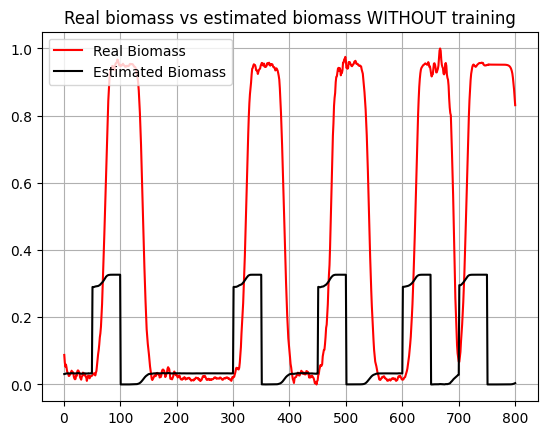

Epoch 1/100
 1/38 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - loss: 0.3440

E0000 00:00:1782986337.139767 31750589 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0595 - val_loss: 0.0013
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 0.0010 - val_loss: 5.0700e-04
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - loss: 3.6527e-04 - val_loss: 3.8660e-04
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - loss: 3.2766e-04 - val_loss: 3.8868e-04
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - loss: 3.2851e-04 - val_loss: 3.8349e-04
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - loss: 3.3162e-04 - val_loss: 3.8959e-04
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - loss: 3.3578e-04 - val_loss: 4.1564e-04
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - loss: 3.4680e-04 - val_loss: 4.5432e-04
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 3.6374e-04 - val_loss: 4.9993e-04
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - loss: 3.8391e-04 - val_loss: 5.1850e-04
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.9826e-04 - va

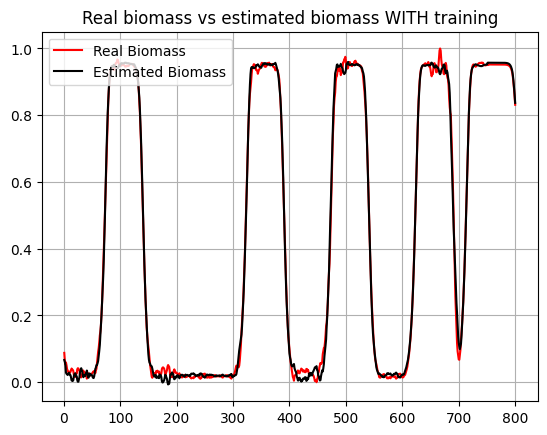

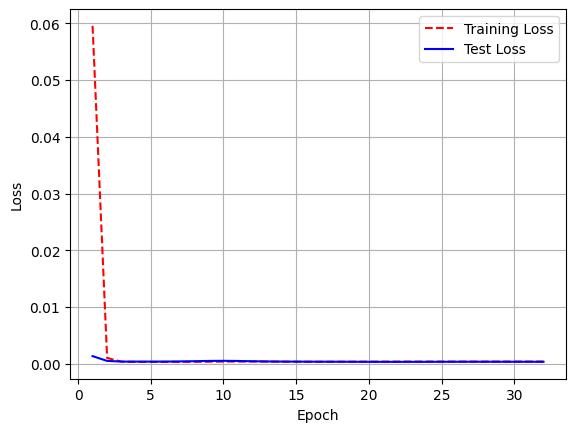

IA = 0.9995293329403078, RMS = 0.030016446819768106, RSD = 0.018432991011974955


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# === Load data ===
i1 = np.loadtxt('compoundA.txt')
i2 = np.loadtxt('substrate.txt')
t1 = np.loadtxt('biomass.txt')
maxData = len(t1)

# === Step 1: Remove negative values ===
i2[i2 < 0] = 0
t1[t1 < 0] = 0

# === Step 2: Smoothing ===
window_length = 11 if maxData > 11 else maxData - (maxData + 1) % 2
i2 = savgol_filter(i2, window_length=window_length, polyorder=2)
t1 = savgol_filter(t1, window_length=window_length, polyorder=2)

# === Step 3: Normalize all inputs to [0, 1] ===
scaler_i1 = MinMaxScaler()
scaler_i2 = MinMaxScaler()
scaler_t1 = MinMaxScaler()

i1 = scaler_i1.fit_transform(i1.reshape(-1, 1)).flatten()
i2 = scaler_i2.fit_transform(i2.reshape(-1, 1)).flatten()
t1 = scaler_t1.fit_transform(t1.reshape(-1, 1)).flatten()

# === Step 4: Create feature matrix and train-test split ===

#TODO

input_features = np.vstack((i1, i2)).T
trainData = 1200

inputTrain = input_features[:trainData]
inputTest = input_features[trainData: maxData]

t1Train = t1[:trainData]
t1Test = t1[trainData:maxData]

# === Step 5: Define and compile model ===


nnet = Sequential()
nnet.add(Input(shape = (2,)))
nnet.add(Dense(29, activation = 'tanh'))
nnet.add(Dense(1, activation='linear'))

nnet.compile(
    loss = 'mean_squared_error',
    optimizer = Adam(learning_rate = 0.01),
)

es = EarlyStopping(
    monitor = 'val_loss',
    mode = 'min',
    patience = 10,
    restore_best_weights = True,
)

# === Step 6: Before-training prediction ===
ynt = nnet.predict(inputTest).flatten()

x = np.arange(1, len(t1Test) + 1)

plt.figure(1)
plt.plot(x, t1Test, 'r-', label='Real Biomass')
plt.plot(x, ynt, 'k-', label='Estimated Biomass')
plt.title('Real biomass vs estimated biomass WITHOUT training')
plt.legend(loc=2)
plt.grid()
plt.show()

# === Step 7: Train the model ===

history = nnet.fit(
    inputTrain,
    t1Train,
    batch_size = 32,
    epochs = 100,
    verbose = 1,
    validation_data = (inputTest, t1Test),
    callbacks = [es]
)

# === Step 8: After-training prediction ===
yt = nnet.predict(inputTest).flatten()

plt.figure(2)
plt.plot(x, t1Test, 'r-', label='Real Biomass')
plt.plot(x, yt, 'k-', label='Estimated Biomass')
plt.title('Real biomass vs estimated biomass WITH training')
plt.legend(loc=2)
plt.grid()
plt.show()

# === Step 9: Training vs validation loss plot ===
epoch_count = range(1, len(history.history['loss']) + 1)

plt.figure(3)
plt.plot(epoch_count, history.history['loss'], 'r--')
plt.plot(epoch_count, history.history['val_loss'], 'b-')
plt.legend(['Training Loss', 'Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()

# === Step 10: Compute IA, RMS, RSD on test data ===
om = np.mean(t1Test)

num = np.sum((t1Test - yt) ** 2)
iaden = np.sum((np.abs(t1Test - om) + np.abs(yt - om)) ** 2)
rmsden = np.sum(t1Test ** 2)

ia = 1 - (num / iaden)
rms = np.sqrt(num / rmsden)
rsd = np.sqrt(num / len(t1Test))

print("IA = %s, RMS = %s, RSD = %s" % (ia, rms, rsd))

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

Main data length: 2000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step


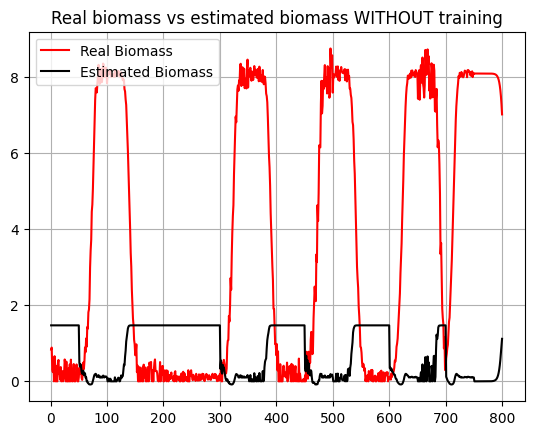

Epoch 1/70
 1/38 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - loss: 28.3795

E0000 00:00:1782983616.194918 31750589 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26.6793 - val_loss: 16.6285
Epoch 2/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 16.1060 - val_loss: 10.5487
Epoch 3/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - loss: 9.3821 - val_loss: 7.0834
Epoch 4/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - loss: 5.7698 - val_loss: 5.1315
Epoch 5/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 3.8805 - val_loss: 3.7462
Epoch 6/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - loss: 2.7284 - val_loss: 2.6963
Epoch 7/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - loss: 1.9481 - val_loss: 1.9321
Epoch 8/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 1.3884 - val_loss: 1.3058
Epoch 9/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.9246 - val_loss: 0.9007
Epoch 10/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.6659 - val_loss: 0.6503
Epoch 11/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - loss: 0.5058 - val_loss: 0.4919
Epoch 12/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - loss: 

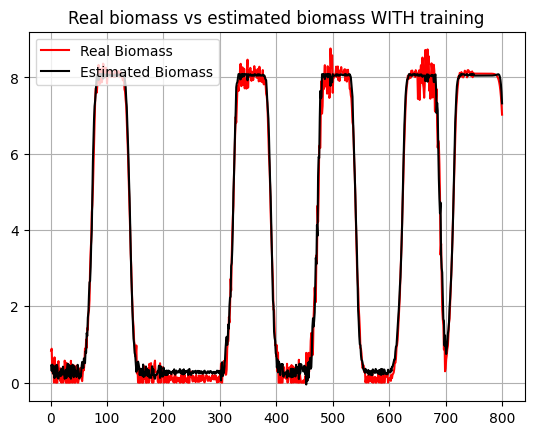

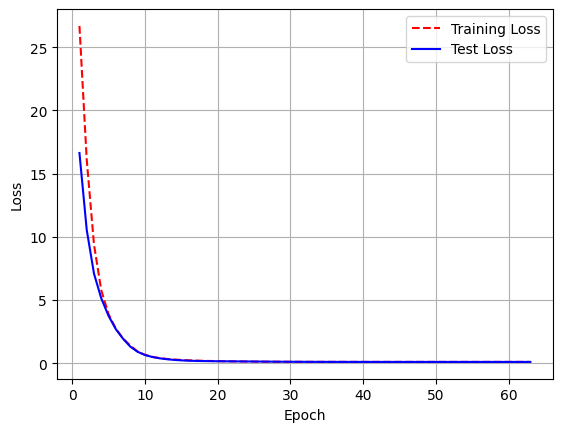

Generalization files not found. Using test data for IA/RMS/RSD.
IA = 0.9980662242859433, RMS = 0.06077204267251041, RSD = 0.31753911911931887


In [16]:
# -*- coding: utf-8 -*-
"""
Created on Sun Jul  2 12:03:37 2023

@author: francisco
"""
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


tf.keras.utils.set_random_seed(313)
tf.config.experimental.enable_op_determinism()


# === Load data ===
i1 = np.loadtxt('compoundA.txt')
i2 = np.loadtxt('substrate.txt')
t1 = np.loadtxt('biomass.txt')

maxData = len(t1)
print("Main data length:", maxData)

# === Simple preprocessing ===
i2[i2 < 0] = 0
t1[t1 < 0] = 0

input_features = np.vstack((i1, i2)).T

trainData = 1200

inputTrain = input_features[:trainData]
inputTest = input_features[trainData:maxData]

t1Train = t1[:trainData]
t1Test = t1[trainData:maxData]

# === Model ===
nnet = Sequential()
nnet.add(Input(shape=(2,)))
nnet.add(Dense(5, activation='tanh'))
nnet.add(Dense(1, activation='linear'))

nnet.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate=0.01)
)

es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
    restore_best_weights=True
)

# === Before training ===
ynt = nnet.predict(inputTest).flatten()

x = np.arange(1, len(t1Test) + 1)

plt.figure(1)
plt.plot(x, t1Test, 'r-', label='Real Biomass')
plt.plot(x, ynt, 'k-', label='Estimated Biomass')
plt.title('Real biomass vs estimated biomass WITHOUT training')
plt.legend(loc=2)
plt.grid()
plt.show()

# === Training ===
history = nnet.fit(
    inputTrain,
    t1Train,
    batch_size=32,
    epochs=70,
    verbose=1,
    validation_data=(inputTest, t1Test),
    callbacks=[es]
)

# === After training ===
yt = nnet.predict(inputTest).flatten()

plt.figure(2)
plt.plot(x, t1Test, 'r-', label='Real Biomass')
plt.plot(x, yt, 'k-', label='Estimated Biomass')
plt.title('Real biomass vs estimated biomass WITH training')
plt.legend(loc=2)
plt.grid()
plt.show()

# === Loss plot ===
epoch_count = range(1, len(history.history['loss']) + 1)

plt.figure(3)
plt.plot(epoch_count, history.history['loss'], 'r--')
plt.plot(epoch_count, history.history['val_loss'], 'b-')
plt.legend(['Training Loss', 'Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()

# === Use generalization data if available; otherwise use test data ===
gen_files_exist = (
    os.path.exists('gen_compoundA.txt') and
    os.path.exists('gen_substrate.txt') and
    os.path.exists('gen_biomass.txt')
)

if gen_files_exist:
    i1Gen = np.loadtxt('gen_compoundA.txt')
    i2Gen = np.loadtxt('gen_substrate.txt')
    t1Gen = np.loadtxt('gen_biomass.txt')

    maxDataGen = len(t1Gen)
    print("Generalization data length:", maxDataGen)

    i2Gen[i2Gen < 0] = 0
    t1Gen[t1Gen < 0] = 0

    inputGen = np.vstack((i1Gen, i2Gen)).T
    ytGen = nnet.predict(inputGen).flatten()

    xGen = np.arange(1, len(t1Gen) + 1)

    plt.figure(4)
    plt.plot(xGen, t1Gen, 'r-', label='Real Biomass')
    plt.plot(xGen, ytGen, 'k-', label='Estimated Biomass')
    plt.title('Real biomass vs estimated biomass GENERALIZATION')
    plt.legend(loc=2)
    plt.grid()
    plt.show()

else:
    print("Generalization files not found. Using test data for IA/RMS/RSD.")
    t1Gen = t1Test
    ytGen = yt

# === IA, RMS, RSD ===
om = np.mean(t1Gen)

num = np.sum((t1Gen - ytGen) ** 2)
iaden = np.sum((np.abs(t1Gen - om) + np.abs(ytGen - om)) ** 2)
rmsden = np.sum(t1Gen ** 2)

ia = 1 - (num / iaden)
rms = np.sqrt(num / rmsden)
rsd = np.sqrt(num / len(t1Gen))

print("IA = %s, RMS = %s, RSD = %s" % (ia, rms, rsd))